# **Heart Disease Detection**
Raphaël TRINQUANT
October, 2025

**Abstract**

This project aims to develop a robust and interpretable machine learning framework for the detection of heart disease. Using the UCI Cleveland Heart Disease dataset (14 attributes), we conducted a comprehensive Exploratory Data Analysis (EDA) followed by a comparative evaluation of Logistic Regression, Decision Trees, and Random Forest classifiers. The Random Forest model emerged as the superior approach, achieving an Accuracy of ~91.6% and an AUC of 0.96.

Beyond predictive performance, this study addresses the "Black Box" limitations of complex algorithms by integrating Explainable AI (XAI) techniques.

Using SHAP (SHapley Additive exPlanations), we provided both global feature importance and individual local explanations to align the model’s decisions with clinical reality. Finally, a critical Fairness Audit revealed a gender bias, with a Recall of 89% for men versus 83% for women. This disparity highlights the challenges of detecting atypical symptoms in female patients and emphasizes the need for "Augmented Intelligence"—combining algorithmic power with human medical oversight—rather than fully automated diagnosis. 

**Source :**

 https://archive.ics.uci.edu/dataset/45/heart+disease + https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland

# Structure

1. [Exploratory Data Analysis](#I.-Exploratory-data-analysis)
2. [Modelisation](#II.-Modelisation)
3. [Interpretability (SHAP)](#III.-Intepretability)
4. [Critical Analysis](#IV.Critical-Analysis:-Errors-and-Robustness)
5. [Conclusion](#V.-Final-Conclusion)


# I. Exploratory data analysis

## 1. Load the dataset

In [1]:
# import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, roc_curve



# Load the dataset
df = pd.read_csv('heart_disease.csv', sep=';')
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Class
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  Class     303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Columns presentation (from Kaggle)


- **Age**: Patients Age in years (Numeric)
- **Sex**: Gender (Male : 1; Female : 0) (Nominal)
- **cp**: Type of chest pain experienced by patient. This term categorized into 4 category. 0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
- **trestbps**: patient's level of blood pressure at resting mode in mm/HG (Numerical)
- **chol**: Serum cholesterol in mg/dl (Numeric)
- **fbs**: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)
- **restecg**: Result of electrocardiogram while at rest are represented in 3 distinct values 0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV) 2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
- **thalach**: Maximum heart rate achieved (Numeric)
- **exang**: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
- **oldpeak**: Exercise induced ST-depression in relative with the state of rest (Numeric)
- **slope**: ST segment measured in terms of slope during peak exercise 0: up sloping; 1: flat; 2: down sloping(Nominal)
- **ca**: The number of major vessels (0–3)(nominal) 
- **thal**: A blood disorder called thalassemia 3: NULL 1: normal blood flow 6: fixed defect (no blood flow in some part of the heart) 7: reversible defect (a blood flow is observed but it is not normal(nominal)
- **Class**: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.


## 2. Traitment of missing values

In [3]:
# number of missing values per column
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

# suppress rows with missing values
df_cleaned = df.dropna()

ca      4
thal    2
dtype: int64

With almost no missing values, we decide to remove these records. The loss of information is insignificant.

However, it's worth noting that Decision Tree and Random Forest models can directly handle these missing data points through surrogate splits. We are not employing this technique at the moment, but we can consider it as it also plays a role in determining feature importance, an interesting dimension when focusing on model explainability.

## 3. Traitment of outliers

In [4]:
# Extraction of categorical columns
nominal_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'Class']
df_binary = df_cleaned[nominal_columns]  

# Extraction of numerical columns
numerical_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_numerical = df_cleaned[numerical_columns]



display(df_binary.head())
display(df_numerical.head())


,sex,cp,fbs,restecg,exang,slope,ca,thal,Class
0,1,1,1,2,0,3,0.0,6.0,0
1,1,4,0,2,1,2,3.0,3.0,1
2,1,4,0,2,1,2,2.0,7.0,1
3,1,3,0,0,0,3,0.0,3.0,0
4,0,2,0,2,0,1,0.0,3.0,0


,age,trestbps,chol,thalach,oldpeak
0,63,145,233,150,2.3
1,67,160,286,108,1.5
2,67,120,229,129,2.6
3,37,130,250,187,3.5
4,41,130,204,172,1.4


In [5]:
# Outliers detection and treatment
for col in df_numerical.columns:
    Q1 = df_numerical[col].quantile(0.25)
    Q3 = df_numerical[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_numerical[(df_numerical[col] < lower_bound) | (df_numerical[col] > upper_bound)]
    print(f'Number of outliers in {col}: {outliers.shape[0]}')

#    df_numerical = df_numerical[(df_numerical[col] >= lower_bound) & (df_numerical[col] <= upper_bound)]

Number of outliers in age: 0
Number of outliers in trestbps: 9
Number of outliers in chol: 5
Number of outliers in thalach: 1
Number of outliers in oldpeak: 5


Almost no atypical values. We choosed to keep all to because in order to preserve the maximum of information.

## 4. Boxplots and distributions

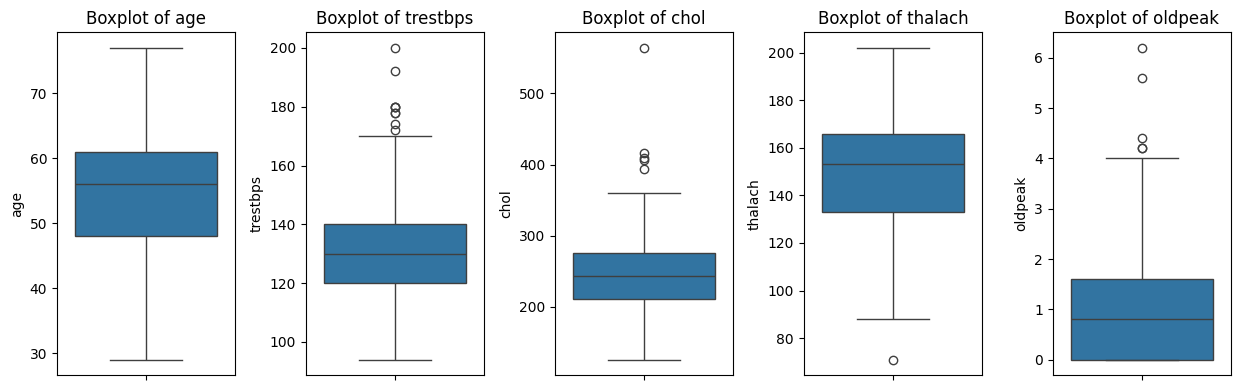

In [6]:
# boxplots
n_cols  = len(df_numerical.columns)

if n_cols > 0:
    
    plots_per_row = 6
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(df_numerical.columns):
        ax = axes[i] 
        sns.boxplot(data=df_numerical, y=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')
        ax.set_ylabel(col)
        ax.set_xlabel('') 

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")

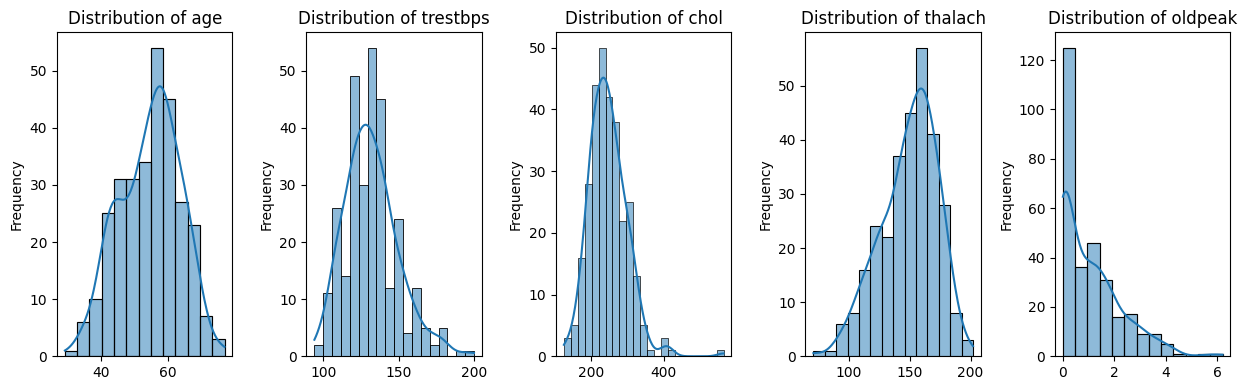

In [7]:
n_cols  = len(df_numerical.columns)
if n_cols > 0:
    
    plots_per_row = 6
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    
    axes = axes.flatten()
    for i, col in enumerate(df_numerical.columns):
        ax = axes[i]  
        sns.histplot(data=df_numerical, x=col, kde=True, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('') 
        ax.set_ylabel('Frequency')

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")


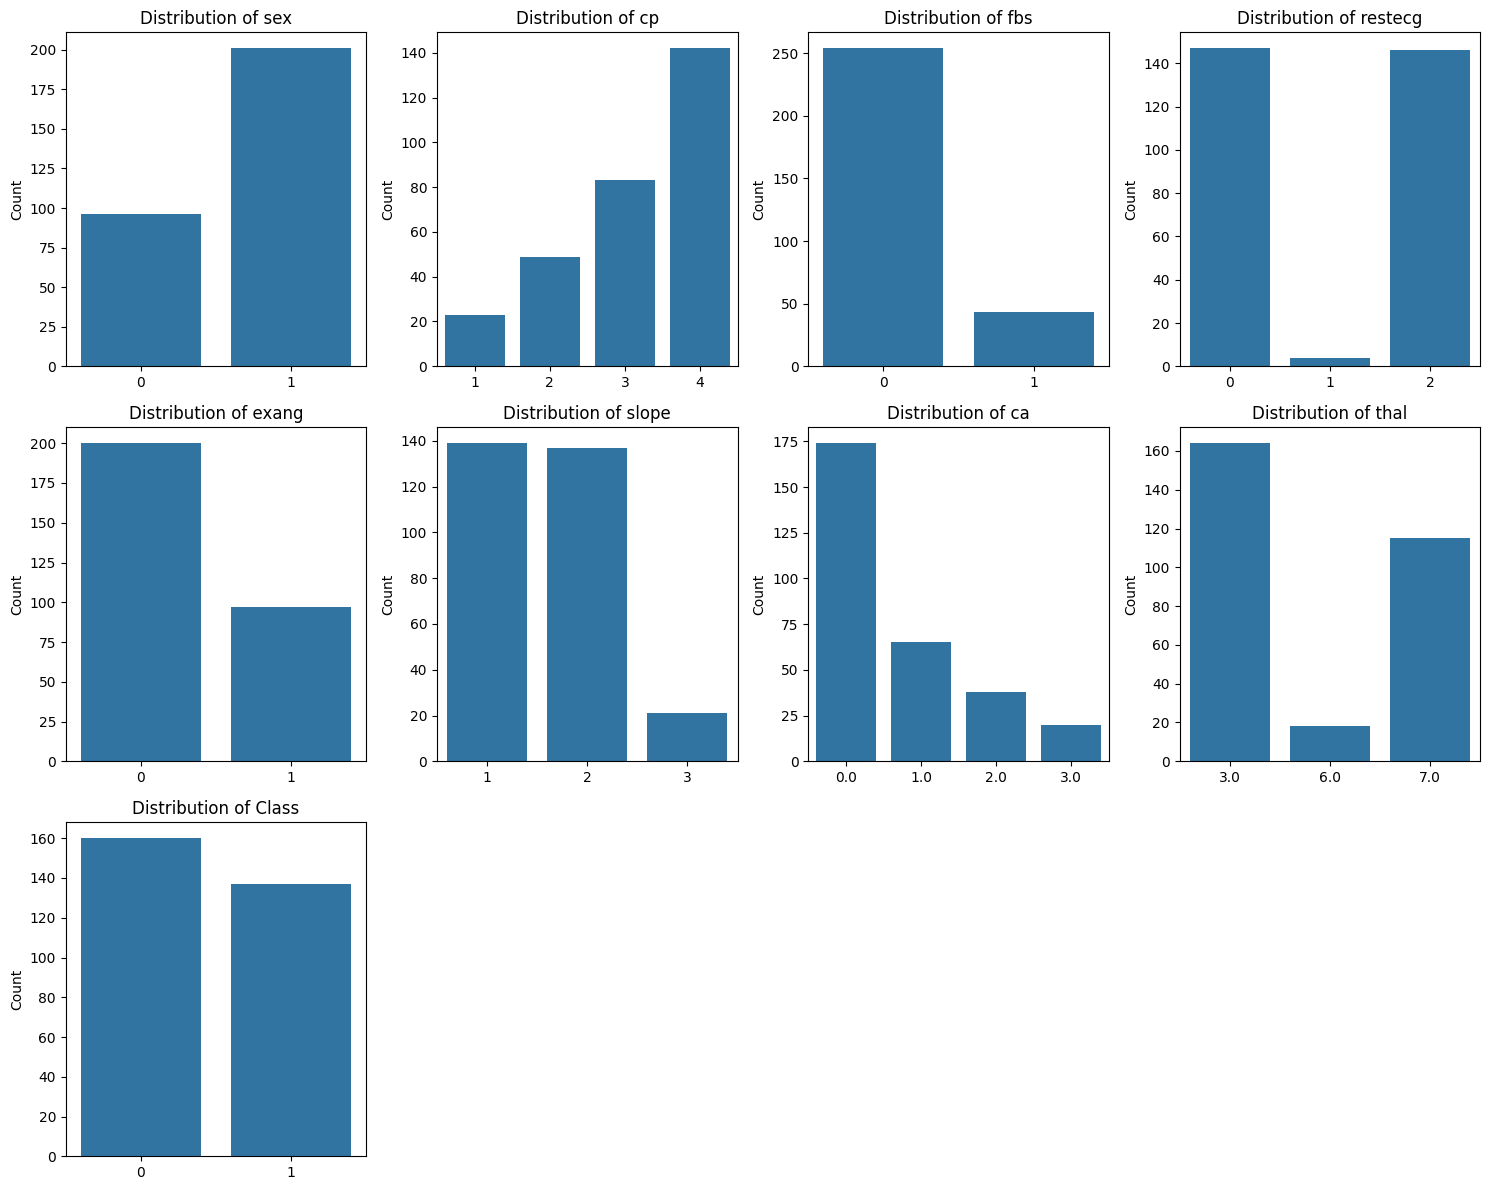

In [8]:
# Display distribution of binary variables
n_cols  = len(df_binary.columns)
if n_cols > 0:
    
    plots_per_row = 4
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    
    axes = axes.flatten()
    for i, col in enumerate(df_binary.columns):
        ax = axes[i]  
        sns.countplot(data=df_binary, x=col, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('') 
        ax.set_ylabel('Count')

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

Box plots and distribution graphs allow us to verify the quality of the data. We observe that the target variable, "Class," is reasonably well balanced. The opposite case could have caused problems in the application of certain models, particularly when trying to detect members of the minority class (e.g., diseased patients/cases).

## 5. Matrix of correlation

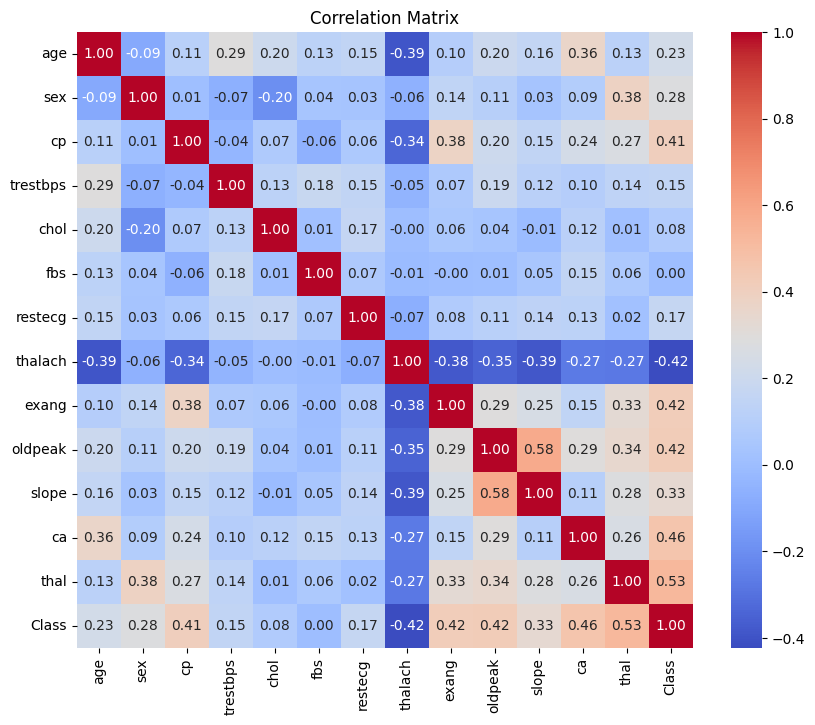

In [9]:
# matrix correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

We do not observe strong collinearity (maximum 0.58). Therefore, we decide to keep all the columns. For the sake of interpretability, we will also not perform Principal Component Analysis (PCA)

# II. Modelisation

## II.1) Logistic Regression

In [10]:
# Data preparation
X = df_cleaned.iloc[:, :-1]
y = df_cleaned.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# Cross-Validation

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
# Make a prediction on the test data
y_pred_lr = model_lr.predict(X_test)

,Logistic Regression
Accuracy,0.8833
Precision,0.8400
Sensitivity,0.8750
Specificity,0.8889
F1-score,0.8571
AUC (ROC),0.9468


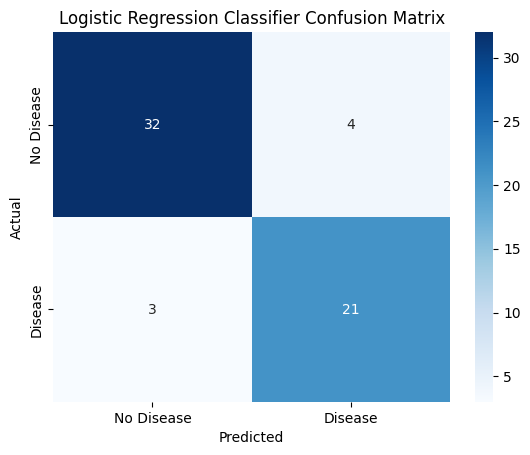

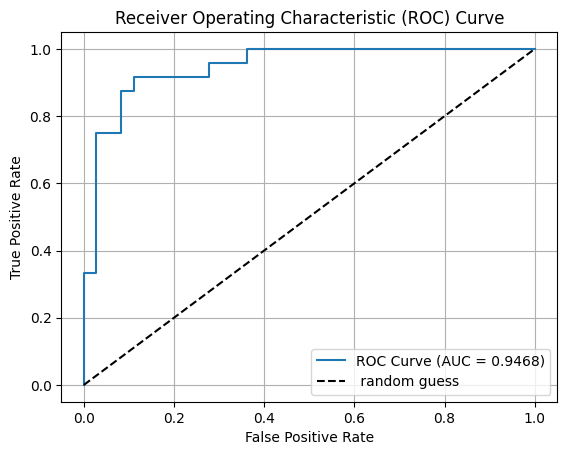

In [12]:
# Evaluation
# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
sensitivity_lr = recall_score(y_test, y_pred_lr)  # sensitivity
cm_lr = confusion_matrix(y_test, y_pred_lr)
specificity_lr = cm_lr[0,0] / (cm_lr[0,0] + cm_lr[0,1]) if (cm_lr[0,0] + cm_lr[0,1]) > 0 else np.nan
f1_lr = f1_score(y_test, y_pred_lr)
auc_score_lr = roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_index = [
     'Accuracy',
     'Precision', 
     'Sensitivity',
     'Specificity',
     'F1-score',
     'AUC (ROC)'
]
metrics_lr = {
     'Logistic Regression': [
          accuracy_lr,
          precision_lr,
          sensitivity_lr,
          specificity_lr,
          f1_lr, 
          auc_score_lr
     ]
}

metrics_lr_df = pd.DataFrame(metrics_lr, index=metrics_index)
display(metrics_lr_df.round(4))

# plot confusion matrix
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, thresholds = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'ROC Curve (AUC = {auc_score_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

## II.2) Decision Tree Method

In [13]:
# Choice of the best hyperparamaters (tuning)
model_dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [None, 2, 3, 5],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [2, 3, 4, 5],
    'ccp_alpha' : [0.03, 0.01, 0]
}

grid_search = GridSearchCV(estimator=model_dt, param_grid=param_grid, cv=5, scoring = 'accuracy')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)
print("Best Estimator:", best_estimator)

# Train the tree with best hyperparameters
model_dt = best_estimator
model_dt.fit(X_train, y_train)

Best Hyperparameters: {'ccp_alpha': 0.01, 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Estimator: DecisionTreeClassifier(ccp_alpha=0.01, min_samples_leaf=5, random_state=42)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


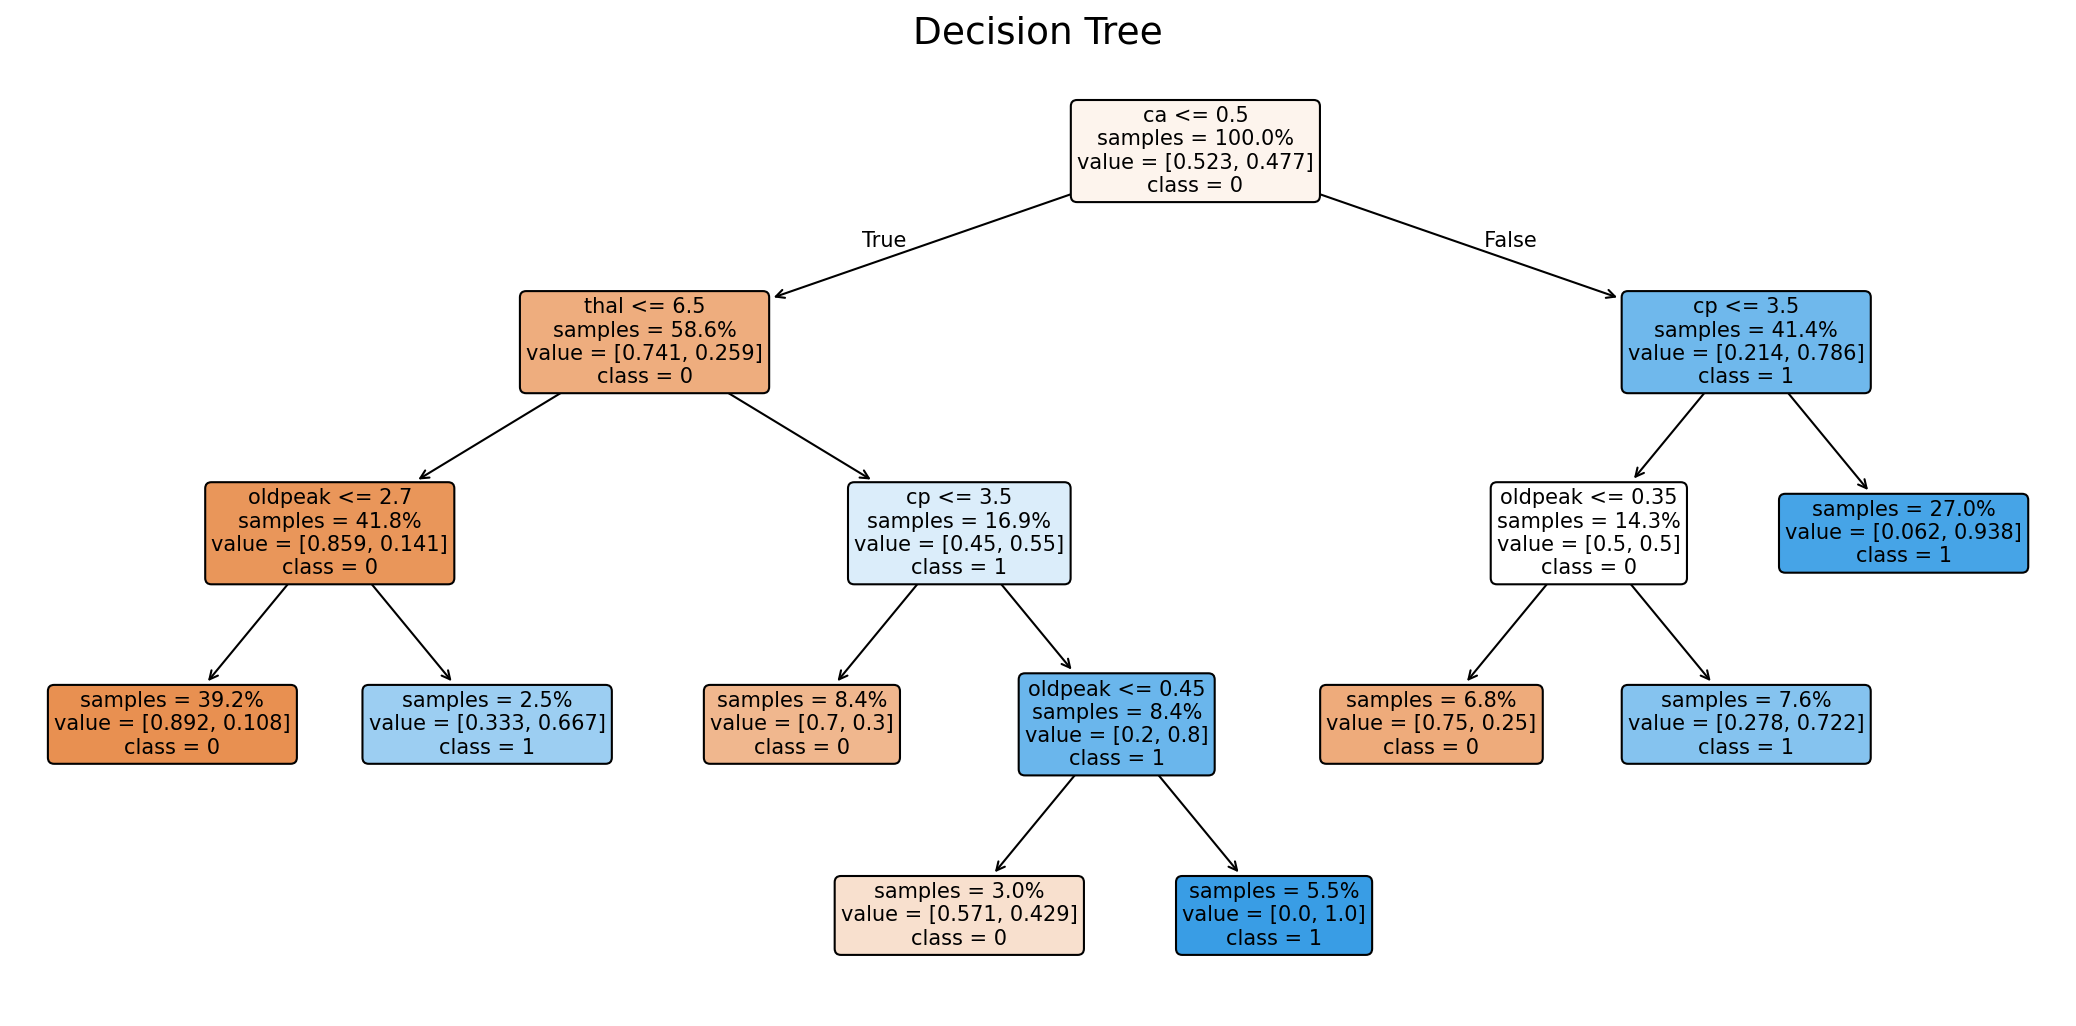

In [14]:
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
class_names = [str(c) for c in model_dt.classes_]
plot_tree(model_dt,
     filled=True,
     rounded=True,
     feature_names=X.columns,
     class_names=class_names,
     proportion=True,
     impurity=False,
     fontsize=10,
     ax=ax)
plt.title("Decision Tree", fontsize=18)
plt.tight_layout()
plt.show()

,Decision Tree
Accuracy,0.7833
Precision,0.7037
Sensitivity,0.7917
Specificity,0.7778
F1-score,0.8571
AUC (ROC),0.8929


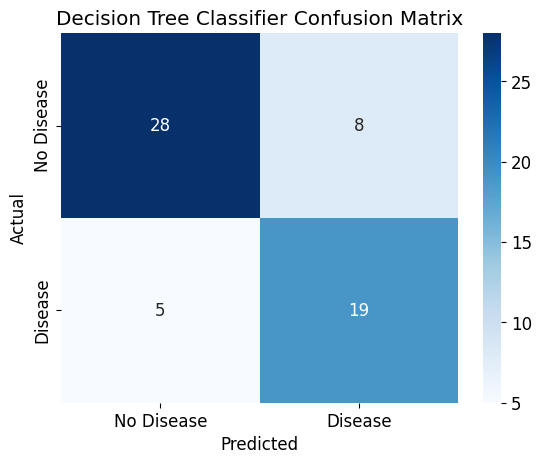

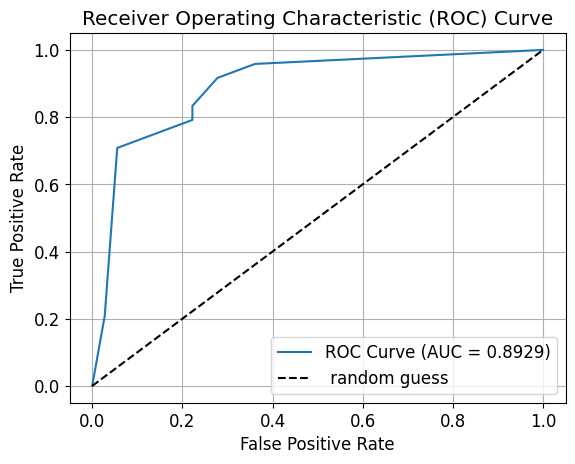

In [15]:
# Evaluation 
y_pred_dt = model_dt.predict(X_test)
# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
sensitivity_dt = recall_score(y_test, y_pred_dt)  # sensitivity
cm_dt = confusion_matrix(y_test, y_pred_dt)
specificity_dt = cm_dt[0,0] / (cm_dt[0,0] + cm_dt[0,1]) if (cm_dt[0,0] + cm_dt[0,1]) > 0 else np.nan
f1_dt = f1_score(y_test, y_pred_lr)
auc_score_dt = roc_auc_score(y_test, model_dt.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_dt = {
     'Decision Tree': [
          accuracy_dt,
          precision_dt,
          sensitivity_dt,
          specificity_dt,
          f1_dt, 
          auc_score_dt
     ]
}

metrics_dt_df = pd.DataFrame(metrics_dt, index=metrics_index)
display(metrics_dt_df.round(4))

# plot confusion matrix
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'ROC Curve (AUC = {auc_score_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()


## II.3) Random Forests 

In [16]:
# create the model and find the best hyperparameters
model_rf = RandomForestClassifier(random_state=42)

param_grid = {
     'n_estimators' : [150, 200],
     'max_samples' : [0.8, 0.9],
     'max_depth' : [2, 3, 5],
     'min_samples_leaf' : [3, 4],
     'ccp_alpha' : [0, 0.01]
}
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)
print("Best Estimator:", best_estimator)


Best Hyperparameters: {'ccp_alpha': 0, 'max_depth': 2, 'max_samples': 0.8, 'min_samples_leaf': 4, 'n_estimators': 150}
Best Estimator: RandomForestClassifier(ccp_alpha=0, max_depth=2, max_samples=0.8,
                       min_samples_leaf=4, n_estimators=150, random_state=42)


In [17]:
# Train the tree with best hyperparameters
model_rf = best_estimator
model_rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,Random Forest
Accuracy,0.9167
Precision,0.9130
Sensitivity,0.8750
Specificity,0.9444
F1-score,0.8936
AUC (ROC),0.9606


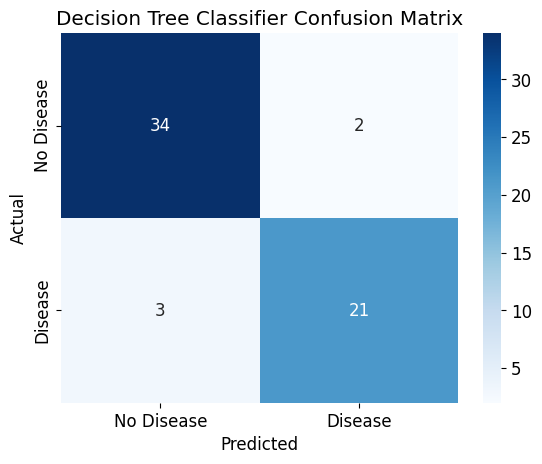

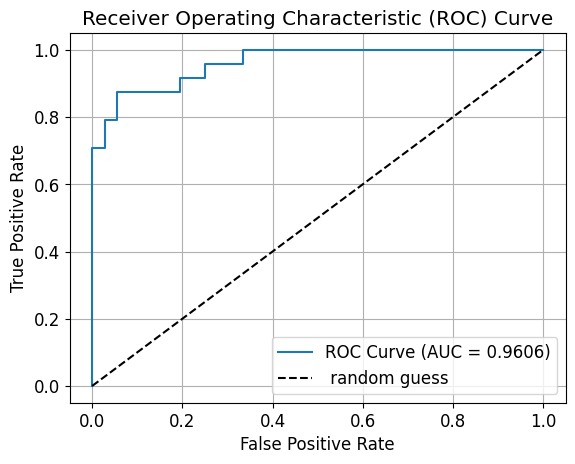

In [18]:
# Evaluation
y_pred_rf = model_rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
sensitivity_rf = recall_score(y_test, y_pred_rf)  # sensitivity
cm_rf = confusion_matrix(y_test, y_pred_rf)
specificity_rf = cm_rf[0,0] / (cm_rf[0,0] + cm_rf[0,1]) if (cm_rf[0,0] + cm_rf[0,1]) > 0 else np.nan
f1_rf = f1_score(y_test, y_pred_rf)
auc_score_rf = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_rf = {
     'Random Forest': [
          accuracy_rf,
          precision_rf,
          sensitivity_rf,
          specificity_rf,
          f1_rf,
          auc_score_rf
     ]
}

metrics_rf_df = pd.DataFrame(metrics_rf, index=metrics_index)
display(metrics_rf_df.round(4))

# plot confusion matrix
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'ROC Curve (AUC = {auc_score_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

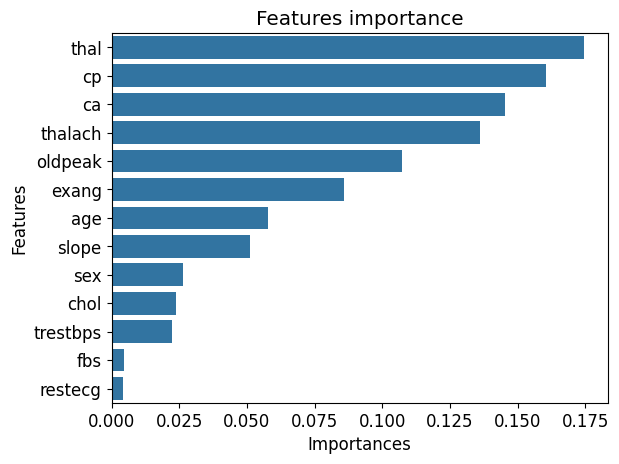

In [19]:
# features importance
feature_importances_rf = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.subplot()
sns.barplot(x=feature_importances_rf.values, y=feature_importances_rf.index)
plt.title("Features importance")
plt.xlabel("Importances")
plt.ylabel("Features")
plt.show()

## II.4) XgBoost

In [20]:
# Create the model and find the optimal hyperparameters
model_xg = xgb.XGBClassifier(random_state=42)
param_grid = {
     'n_estimators' : [100, 150, 200],
     'learning_rate' : [0.1, 0.2],
     'max_depth' : [2, 3],
     'subsample' : [0.8, 0.9],
     'colsample_bytree' : [0.8, 0.9]
}
grid_search = GridSearchCV(estimator=model_xg, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)
print("Best Estimator:", best_estimator)

Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.8}
Best Estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)


In [21]:
# train the model
model_xg = best_estimator
model_xg.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


,XGBoost
Accuracy,0.8667
Precision,0.7857
Sensitivity,0.9167
Specificity,0.8333
F1-score,0.8571
AUC (ROC),0.9213


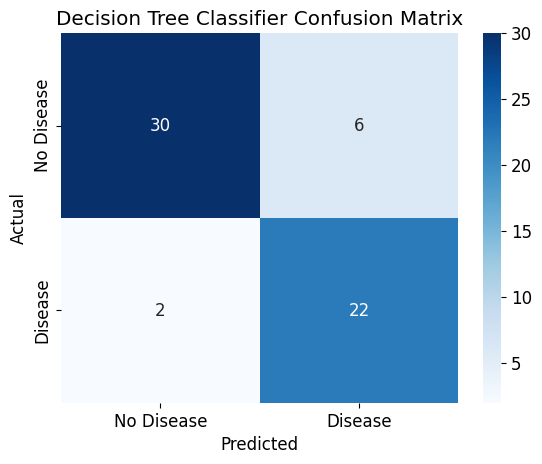

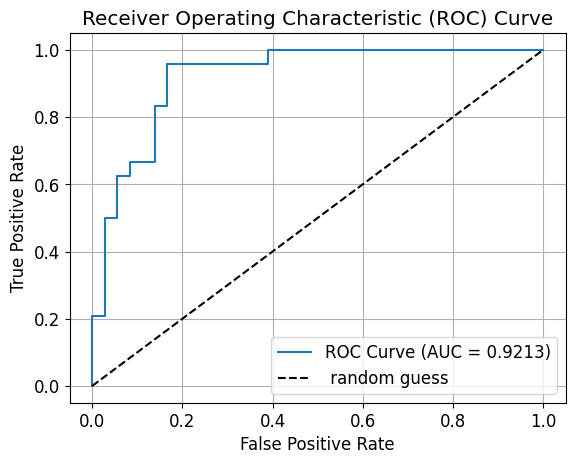

In [22]:
# Evaluation 
y_pred_xg = model_xg.predict(X_test)
# Calculate metrics
accuracy_xg = accuracy_score(y_test, y_pred_xg)
precision_xg = precision_score(y_test, y_pred_xg)
sensitivity_xg = recall_score(y_test, y_pred_xg)  # sensitivity
cm_xg = confusion_matrix(y_test, y_pred_xg)
specificity_xg = cm_xg[0,0] / (cm_xg[0,0] + cm_xg[0,1]) if (cm_xg[0,0] + cm_xg[0,1]) > 0 else np.nan
f1_xg = f1_score(y_test, y_pred_lr)
auc_score_xg = roc_auc_score(y_test, model_xg.predict_proba(X_test)[:,1]) 

# Print metrics
metrics_xg = {
     'XGBoost': [
          accuracy_xg,
          precision_xg,
          sensitivity_xg,
          specificity_xg,
          f1_xg,
          auc_score_xg
     ]
}

metrics_xg_df = pd.DataFrame(metrics_xg, index=metrics_index)
display(metrics_xg_df.round(4))

# plot confusion matrix
sns.heatmap(cm_xg, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier Confusion Matrix")
plt.show()

# plot ROC curv
y_prob_xg = model_xg.predict_proba(X_test)[:, 1]
fpr_xg, tpr_xg, thresholds = roc_curve(y_test, y_prob_xg)
plt.plot(fpr_xg, tpr_xg, label=f'ROC Curve (AUC = {auc_score_xg:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

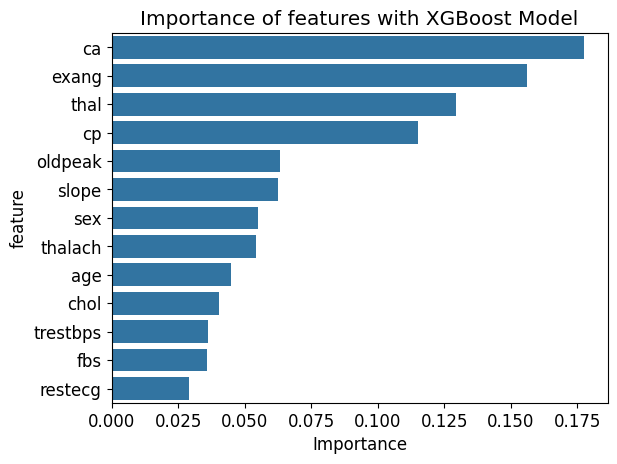

In [23]:
# features importances
feature_importances_xg = pd.Series(model_xg.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importances_xg.values, y=feature_importances_xg.index)
plt.title("Importance of features with XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("feature")
plt.show()

The results for feature importance are broadly similar. We can observe that the XGBoost model is slightly more balanced, whereas the Random Forest model has effectively eliminated the last two variables. We should also question the stability of these results. One potential avenue for improvement could be the integration of surrogate splits.

## II.5) Comparison

,Logistic Regression,Decision Tree,Random Forest,XGboost
Accuracy,0.883333,0.783333,0.916667,0.866667
Precision,0.840000,0.703704,0.913043,0.785714
Sensitivity,0.875000,0.791667,0.875000,0.916667
Specificity,0.888889,0.777778,0.944444,0.833333
F1-score,0.857143,0.857143,0.893617,0.857143
AUC (ROC),0.946759,0.892940,0.960648,0.921296


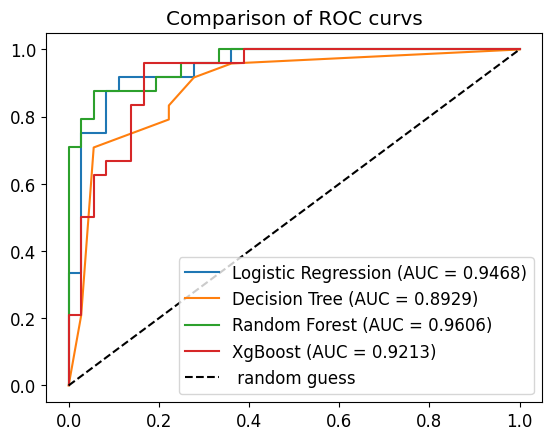

In [24]:
# Compare metrics
comparison_df = pd.DataFrame({
     'Logistic Regression' : metrics_lr['Logistic Regression'],
     'Decision Tree' : metrics_dt['Decision Tree'], 
     'Random Forest' : metrics_rf['Random Forest'],
     'XGboost' : metrics_xg['XGBoost']
}, index=metrics_index)
display(comparison_df)

# plot ROC curv
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_score_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_score_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_score_rf:.4f})')
plt.plot(fpr_xg, tpr_xg, label=f'XgBoost (AUC = {auc_score_xg:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.title("Comparison of ROC curvs")
plt.legend()
plt.show()


Considering all these metrics, the most performant model is the Random Forest. However, we still note that the XGBoost model yields a higher sensitivity (or Recall).

In our case, the cost of a False Negative is very high. Indeed, failing to detect the presence of a serious disease in a patient significantly decreases their chances of survival. For instance, consider this statistic: localized breast cancer offers an average net 5-year survival rate of over 90%, whereas this rate drops substantially for non-localized forms. (Source: https://radiotherapie-hartmann.fr/actualites/divers/chances-survie-associees-aux-cancers/). Conversely, we imagine that a False Positive would be quickly ruled out after subsequent tests.

Therefore, one avenue for future consideration would be to integrate this cost knowledge by updating the priors in our model. We should also highlight the good performance of Logistic Regression (AUC=0.9213) considering the model's simplicity, especially when compared to the lower score of the Decision Tree model.



# III. Interpretability

**Motivation:** Although our Random Forest model has demonstrated excellent performance (Accuracy ~91.6% and AUC ~0.96), it suffers from a major flaw inherent to complex algorithms: it is a "Black Box."

In the medical field, raw performance is not sufficient. A clinician cannot accept a diagnosis based on an opaque probability; they must understand the clinical factors justifying the algorithm's decision to validate its consistency with the patient's biological reality.

**Objective:** This section aims to bridge the gap between data science and clinical practice using the SHAP (SHapley Additive exPlanations) method. Based on game theory, this approach will enable us to:

    Validate the model's global consistency: Verify that key variables (chest pain, thalassemia) influence the model in the medically expected direction.

    Provide local explanations: Justify the risk score for each individual patient by quantifying the exact contribution of each symptom to their personal diagnosis (Precision Medicine).

X_test shape: (60, 13)
SHAP values shape (Class 1): (60, 13)


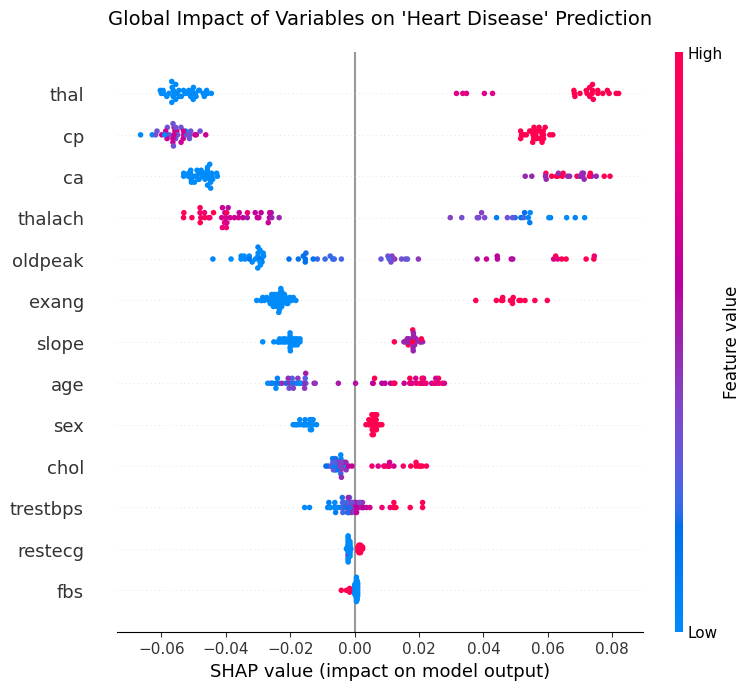

In [25]:
import shap

# JS Initialization
shap.initjs()

# 1. Create the explainer
explainer = shap.TreeExplainer(model_rf)

# 2. Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# 3. Handle shap_values format (List vs 3D Array) to target the "Disease" class (1)
if isinstance(shap_values, list):
    # Classic sklearn case: list of [array_class0, array_class1]
    shap_values_disease = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # Case sometimes encountered: array of shape (samples, features, classes)
    shap_values_disease = shap_values[:, :, 1]
else:
    # Simple binary case or regression
    shap_values_disease = shap_values

# Safety check (optional, for debug)
print(f"X_test shape: {X_test.shape}")
print(f"SHAP values shape (Class 1): {shap_values_disease.shape}")

# 4. Display Global Summary (Beeswarm plot)

plt.figure()
shap.summary_plot(shap_values_disease, X_test, show=False)
plt.title("Global Impact of Variables on 'Heart Disease' Prediction", fontsize=14, pad=20)
plt.show()

**Interpretation of SHAP Values and Comparative Analysis**

1. Insights from the SHAP Summary Plot The SHAP Beeswarm plot corroborates the clinical validity of the Random Forest model, providing transparency into its decision-making process:

    Feature Hierarchy: The analysis confirms that Thalassemia (thal), Chest Pain Type (cp), and the Number of Major Vessels (ca) are the most significant determinants for the diagnosis.

    Clinical Logic: Unlike standard metrics, this visualization reveals the nature of each feature's influence. We observe that elevated values for thal, cp, ca, and oldpeak (indicated by red points) are strongly associated with an increased probability of heart disease (positive SHAP values). Conversely, the Maximum Heart Rate (thalach) acts as a protective factor: higher values contribute to a lower risk prediction (shifting points to the left, towards the "healthy" class).

2. Comparison with Standard Feature Importance When contrasting these findings with the previously computed Feature Importance (based on Gini impurity):

    Consistency in Ranking: Both methods converge on the identification of key predictors. The leading variables (thal, cp) remain consistent across both evaluations, demonstrating the robustness of the model.

    Added Value of SHAP: The primary advantage of the SHAP analysis lies in its interpretability. While standard Feature Importance quantifies the magnitude of a variable's impact, it remains "blind" to the nature of that impact. SHAP, however, provides directionality. It does not merely state that heart rate is important; it explicitly clarifies that a low heart rate is a risk factor. This nuance shifts the analysis from a purely statistical observation to a clinically relevant explanation, which is essential for fostering trust with medical practitioners.

In [26]:
# For a single patient 
shap.force_plot(explainer.expected_value[1], shap_values_disease[55,:], X_test.iloc[3,:])

**Local Analysis: Explaining the Prediction for a Specific Patient**

To understand the model's decision at an individual level, we use a Force Plot. This chart visualizes how each feature of the patient contributes to shifting the prediction away from the baseline average (Base Value). It illustrates the "tug-of-war" between factors that increase the risk (in red) and those that decrease it (in blue).

Case Interpretation: The model predicts a 63% risk for this patient (compared to a population average of 47%). This elevated risk is primarily driven by:

    Their Chest Pain type (cp = 4), which is a strong indicator.

    Their Thalassemia test result (thal = 3).

    Their low maximum heart rate during exercise (thalach = 109), signaling reduced cardiac performance.

    Age (70) also plays an aggravating role, though to a lesser extent.

Conversely, we note that certain factors, such as the number of colored vessels (ca=3), attempt to moderate this score but are insufficient to offset the dominant risk factors.

In [27]:
# Aggregated SHAP Force Plot
shap.force_plot(explainer.expected_value[1], shap_values_disease, X_test)

This graph is an Aggregated SHAP Force Plot. It stacks the force plots of all patients in your test set, rotated 90 degrees, and orders them by similarity to reveal patterns across the population.
This plot confirms that the model differentiates well between distinct patient profiles (clearly sick vs. clearly healthy) and handles complex, conflicting cases (the left side) by weighing competing evidence.

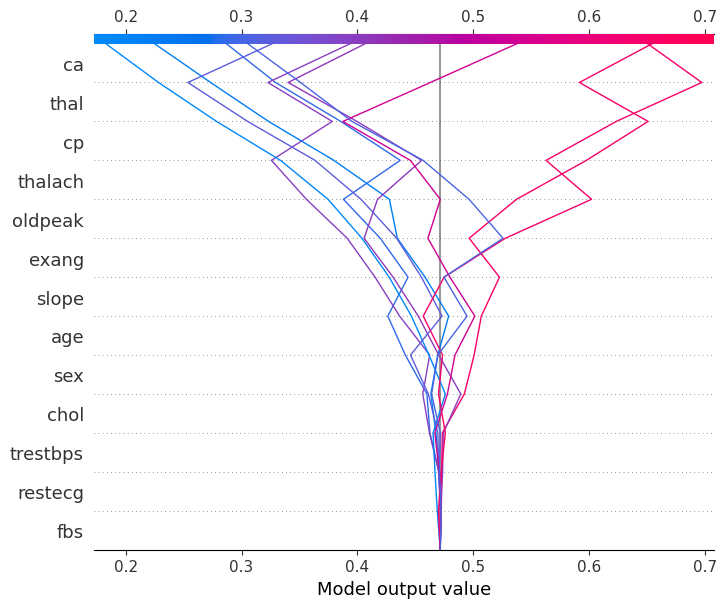

In [28]:
# Compare decisions for 10 patients
shap.decision_plot(explainer.expected_value[1], shap_values_disease[:10], X_test.iloc[:10])

The **Decision Plot** allows us to trace the model's decision path. Reading from bottom to top, we observe how the sequential addition of each symptom shifts the prediction towards risk (right) or health (left). It is the ideal tool for understanding the cumulative dynamics of risk factors.

Analysis of the first 10 patients in the test set reveals an interesting dynamic. While general risk factors such as cholesterol or blood pressure (trestbps, chol) have minimal impact on the final decision, the model relies heavily on the results of advanced clinical examinations.

We observe a clear divergence in trajectories starting from the stress test (oldpeak). However, the ca (fluoroscopy) and thal variables act as the final determinants, driving the probabilities toward the extremes (0 or 1) to confirm the diagnosis.

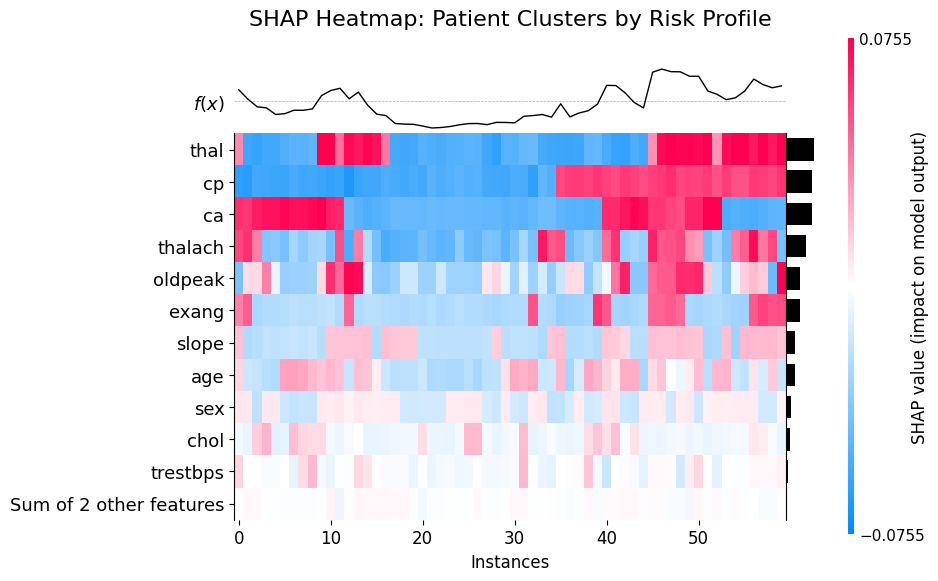

In [29]:
# 1. Properly recreate the "Explanation" object required by the Heatmap
# This combines raw values, the base value (mean), and patient data
explanation = shap.Explanation(
    values=shap_values_disease,           # Your calculated SHAP values (class 1)
    base_values=explainer.expected_value[1], # The average probability (class 1)
    data=X_test,                          # Patient data
    feature_names=X_test.columns          # Column names
)

# 2. Displaying the Heatmap
plt.figure(figsize=(12, 6))

# We remove "instance_order" which was causing issues.
# By default, SHAP will still perform hierarchical clustering (hclust).
shap.plots.heatmap(explanation, max_display=12, show=False)

plt.title("SHAP Heatmap: Patient Clusters by Risk Profile", fontsize=16, pad=20)
plt.show()

**SHAP Heatmap Interpretation: Patient Clustering**

The SHAP Heatmap provides a global view of the test set, ordering patients by similarity to reveal distinct clinical profiles:

- The "Healthy" Cluster (Left): Defined by a low predictive curve (f(x)) and a dominance of blue values. These patients are protected by the absence of key risk factors (normal thallium test, no chest pain, no colored vessels).

- The "High-Risk" Cluster (Right): Characterized by a peak in predicted probability and a vertical "wall of red." For these patients, risk factors accumulate: they simultaneously exhibit reversible defects (thal), asymptomatic chest pain (cp), and multiple blocked vessels (ca).

- The "Transition" Zone (Middle): Represents complex cases where signals are mixed (e.g., presence of chest pain but normal thallium results), leading to moderate risk predictions.

Conclusion: This visualization confirms that the model does not output random probabilities but structures its decisions around coherent medical patterns. It clearly highlights Thalassemia (thal) and Chest Pain Type (cp) as the primary "switches" for diagnosis: when both indicators turn red, the predicted risk of heart disease becomes maximal.

# IV. Critical Analysis: Errors and Robustness


Having established the predictive performance and interpretability of our Random Forest model, it is essential to conduct a critical assessment of its reliability in a clinical setting. High accuracy metrics alone do not guarantee safety; therefore, this final section focuses on Error Analysis and Fairness. We will investigate the specific causes of misclassifications—particularly false negatives that pose a risk to patient safety—and evaluate potential biases across demographic groups to ensure the model offers a robust, ethical, and equitable diagnostic tool.

## 1. Analysis of "False Negative" 

Variable 'idx_fn' définie sur l'index : 1
Predicted probability for this patient: 0.39


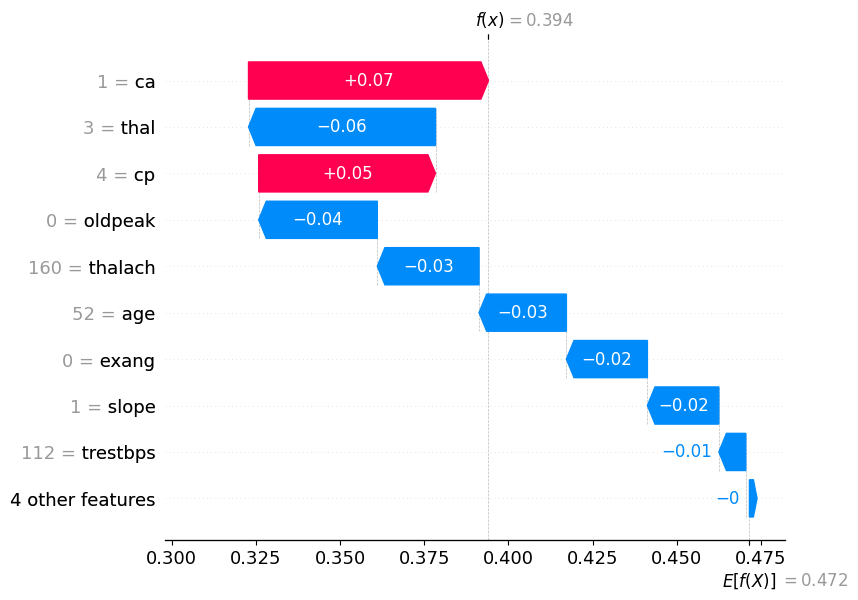

In [34]:
# 1. Retrieve data for the specific False Negative patient
# Using double brackets [[idx_fn]] ensures we keep it as a DataFrame (1 row)

# 1. On fait les prédictions
y_pred = model_rf.predict(X_test)

# 2. On cherche les indices où : Vérité = 1 (Malade) ET Prédiction = 0 (Sain)
false_negatives = [i for i, (truth, pred) in enumerate(zip(y_test, y_pred)) if truth == 1 and pred == 0]

# 3. On récupère le premier index trouvé
if len(false_negatives) > 0:
    idx_fn = false_negatives[0]
    print(f"Variable 'idx_fn' définie sur l'index : {idx_fn}")
else:
    print("Aucun Faux Négatif trouvé. 'idx_fn' n'a pas été défini.")
patient_data = X_test.iloc[[idx_fn]] 

# 2. Recalculate SHAP values JUST for this patient
# This avoids indexing errors that can occur with the large shap_values array
shap_values_single = explainer.shap_values(patient_data)

# 3. Robust data structure handling (List vs 3D Array)
if isinstance(shap_values_single, list):
    # For binary classifiers, this is often a list of 2 arrays (Class 0, Class 1)
    # We select index 1 for the "Disease" class
    # We select [0] because we only passed a single row of data
    values_to_plot = shap_values_single[1][0]
    base_value = explainer.expected_value[1]
else:
    # Case for 3D arrays (n_samples, n_features, n_classes)
    values_to_plot = shap_values_single[0, :, 1]
    base_value = explainer.expected_value[1]

# 4. Create a clean Explanation object
exp = shap.Explanation(
    values=values_to_plot,
    base_values=base_value,
    data=patient_data.iloc[0],  # .iloc[0] converts the row back to a Series for display
    feature_names=X_test.columns
)

# 5. Display the plot
print(f"Predicted probability for this patient: {base_value + values_to_plot.sum():.2f}")

# Force display of the top 10 features to see the full picture
shap.plots.waterfall(exp, max_display=10)

**Analysis of a False Negative (Missed Diagnosis)**

This Waterfall plot illustrates why the model failed to detect heart disease in this specific patient, assigning a probability of 39.4% (below the 50% threshold).

The plot reveals a clear conflict between clinical history and functional capacity:

    Risk Factors (Red): The model correctly identified alarm signals, specifically ca = 1 (presence of colored vessels via fluoroscopy) and cp = 4 (chest pain type), which combined to push the risk probability up by +12%.

    Masking Factors (Blue): However, these warning signs were overwhelmed by the patient's apparent physiological fitness. The absence of exercise-induced abnormalities (oldpeak = 0, exang = 0) and a relatively healthy maximum heart rate (thalach = 160) acted as strong "protective" factors.

Conclusion: The algorithm was "reassured" by the patient's good performance during physical stress tests (stress test variables), which effectively masked the anatomical risks suggesting the disease. This highlights a limitation where the model may prioritize functional metrics over anatomical markers in borderline cases.

## 2. Bias Analysis (Fairness)

In [ ]:
from sklearn.metrics import recall_score

# Separation by sex
X_test_hommes = X_test[X_test['sex'] == 1]
y_test_hommes = y_test[X_test['sex'] == 1]
X_test_femmes = X_test[X_test['sex'] == 0]
y_test_femmes = y_test[X_test['sex'] == 0]

# Recall (Sensibility) by group
recall_h = recall_score(y_test_hommes, model_rf.predict(X_test_hommes))
recall_f = recall_score(y_test_femmes, model_rf.predict(X_test_femmes))

print(f"Men Recall : {recall_h:.2f}")
print(f"Women Recall : {recall_f:.2f}")

Men Recall : 0.89
Women Recall : 0.83


**Motivation**

While the model's overall accuracy is high, aggregate metrics can conceal critical disparities within patient subgroups. In the medical field, a model must not merely be "accurate on average"; it must be equitable.

It is clinically established that cardiovascular diseases exhibit sexual dimorphism: symptoms and pathophysiology differ between men and women (with women often presenting atypical symptoms).

If our training dataset is imbalanced (predominantly male) or if the model fails to capture the subtleties of female symptoms, we risk creating algorithmic bias. Therefore, this section aims to verify that our AI does not compromise the safety of female patients to maximize its global score, by specifically comparing Recall (sensitivity) across genders.

**Model Fairness Analysis**

The segmented evaluation of sensitivity (Recall) reveals a notable performance disparity between genders. While the model correctly identifies 89% of sick male patients, this performance drops to 83% for female patients.

This 6-point gap suggests that the model struggles more to capture the "signature" of heart disease in women. This difficulty likely reflects a known medical reality: the clinical presentation of myocardial infarction is often "atypical" in women (symptoms are less pronounced than in men), making classic variables (such as chest pain type, cp) less discriminatory.

**Conclusion:**

Although performing well overall, the model exhibits a bias of under-diagnosis towards the female population, necessitating increased vigilance from the practitioner when analyzing female patient records.

# V. Final Conclusion

This study led to the development and analysis of a Random Forest model designed for the prediction of cardiovascular diseases. This project has demonstrated the potential of machine learning as a decision support tool in cardiology, while highlighting the imperative need for rigorous interpretability.

1. Performance and Robustness From a purely metric perspective, the model achieved excellent performance with an Accuracy of ~91.6% and an AUC of 0.96. It effectively prioritized risk factors, correctly identifying major clinical variables (chest pain, thalassemia, fluoroscopy results) as the primary determinants.

2. The Contribution of Explainability (SHAP) The integration of the SHAP method transformed a "Black Box" into a transparent tool.

- Globally, we validated that the model adheres to medical logic (risk factors correctly increase disease probability).

- Locally, we were able to justify each individual diagnosis. The error analysis (False Negatives) revealed that the model can sometimes be "over-reassured" by strong performance in stress tests, thereby masking concerning anatomical signs.

3. Ethical Limits and Bias The fairness audit highlighted a critical limitation: a performance bias based on gender. With a detection rate (Recall) of 89% in men versus 83% in women, the model inadvertently reproduces historical disparities in medical research. This potential under-diagnosis in women requires increased vigilance when using the tool on this specific population.

Synthesis In conclusion, this algorithm should not be viewed as a replacement for the cardiologist, but rather as a powerful digital "Second Opinion." For clinical deployment, it would be imperative to retrain the model on a more balanced dataset and to integrate systematic human validation, particularly for female or atypical profiles. We thus shift from a logic of Artificial Intelligence to one of Augmented Intelligence.